# Diabetes Prediction Challenge
This is a kaggle playground competition where we are trying to classify if a individual has diabetes or not. Target variable is diagnosed_diabetes.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

# Exploratory Data Analysis

In [4]:
train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [6]:
train.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
train.isna().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


Looks like we have no missing values so will not need to worry about filling those in.

<Axes: xlabel='diagnosed_diabetes', ylabel='count'>

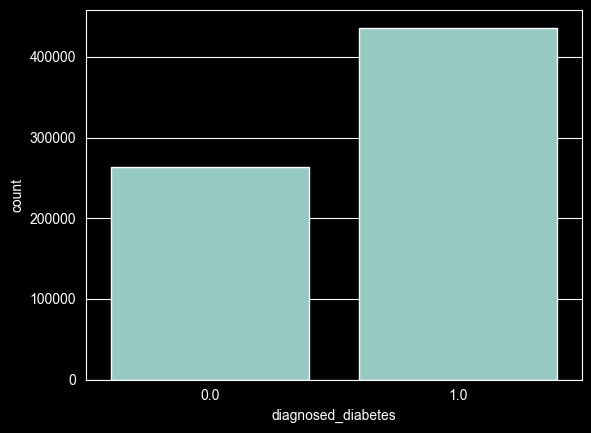

In [8]:

sns.countplot(train, x = "diagnosed_diabetes")

Looks like we have a bit of an unequal target value.

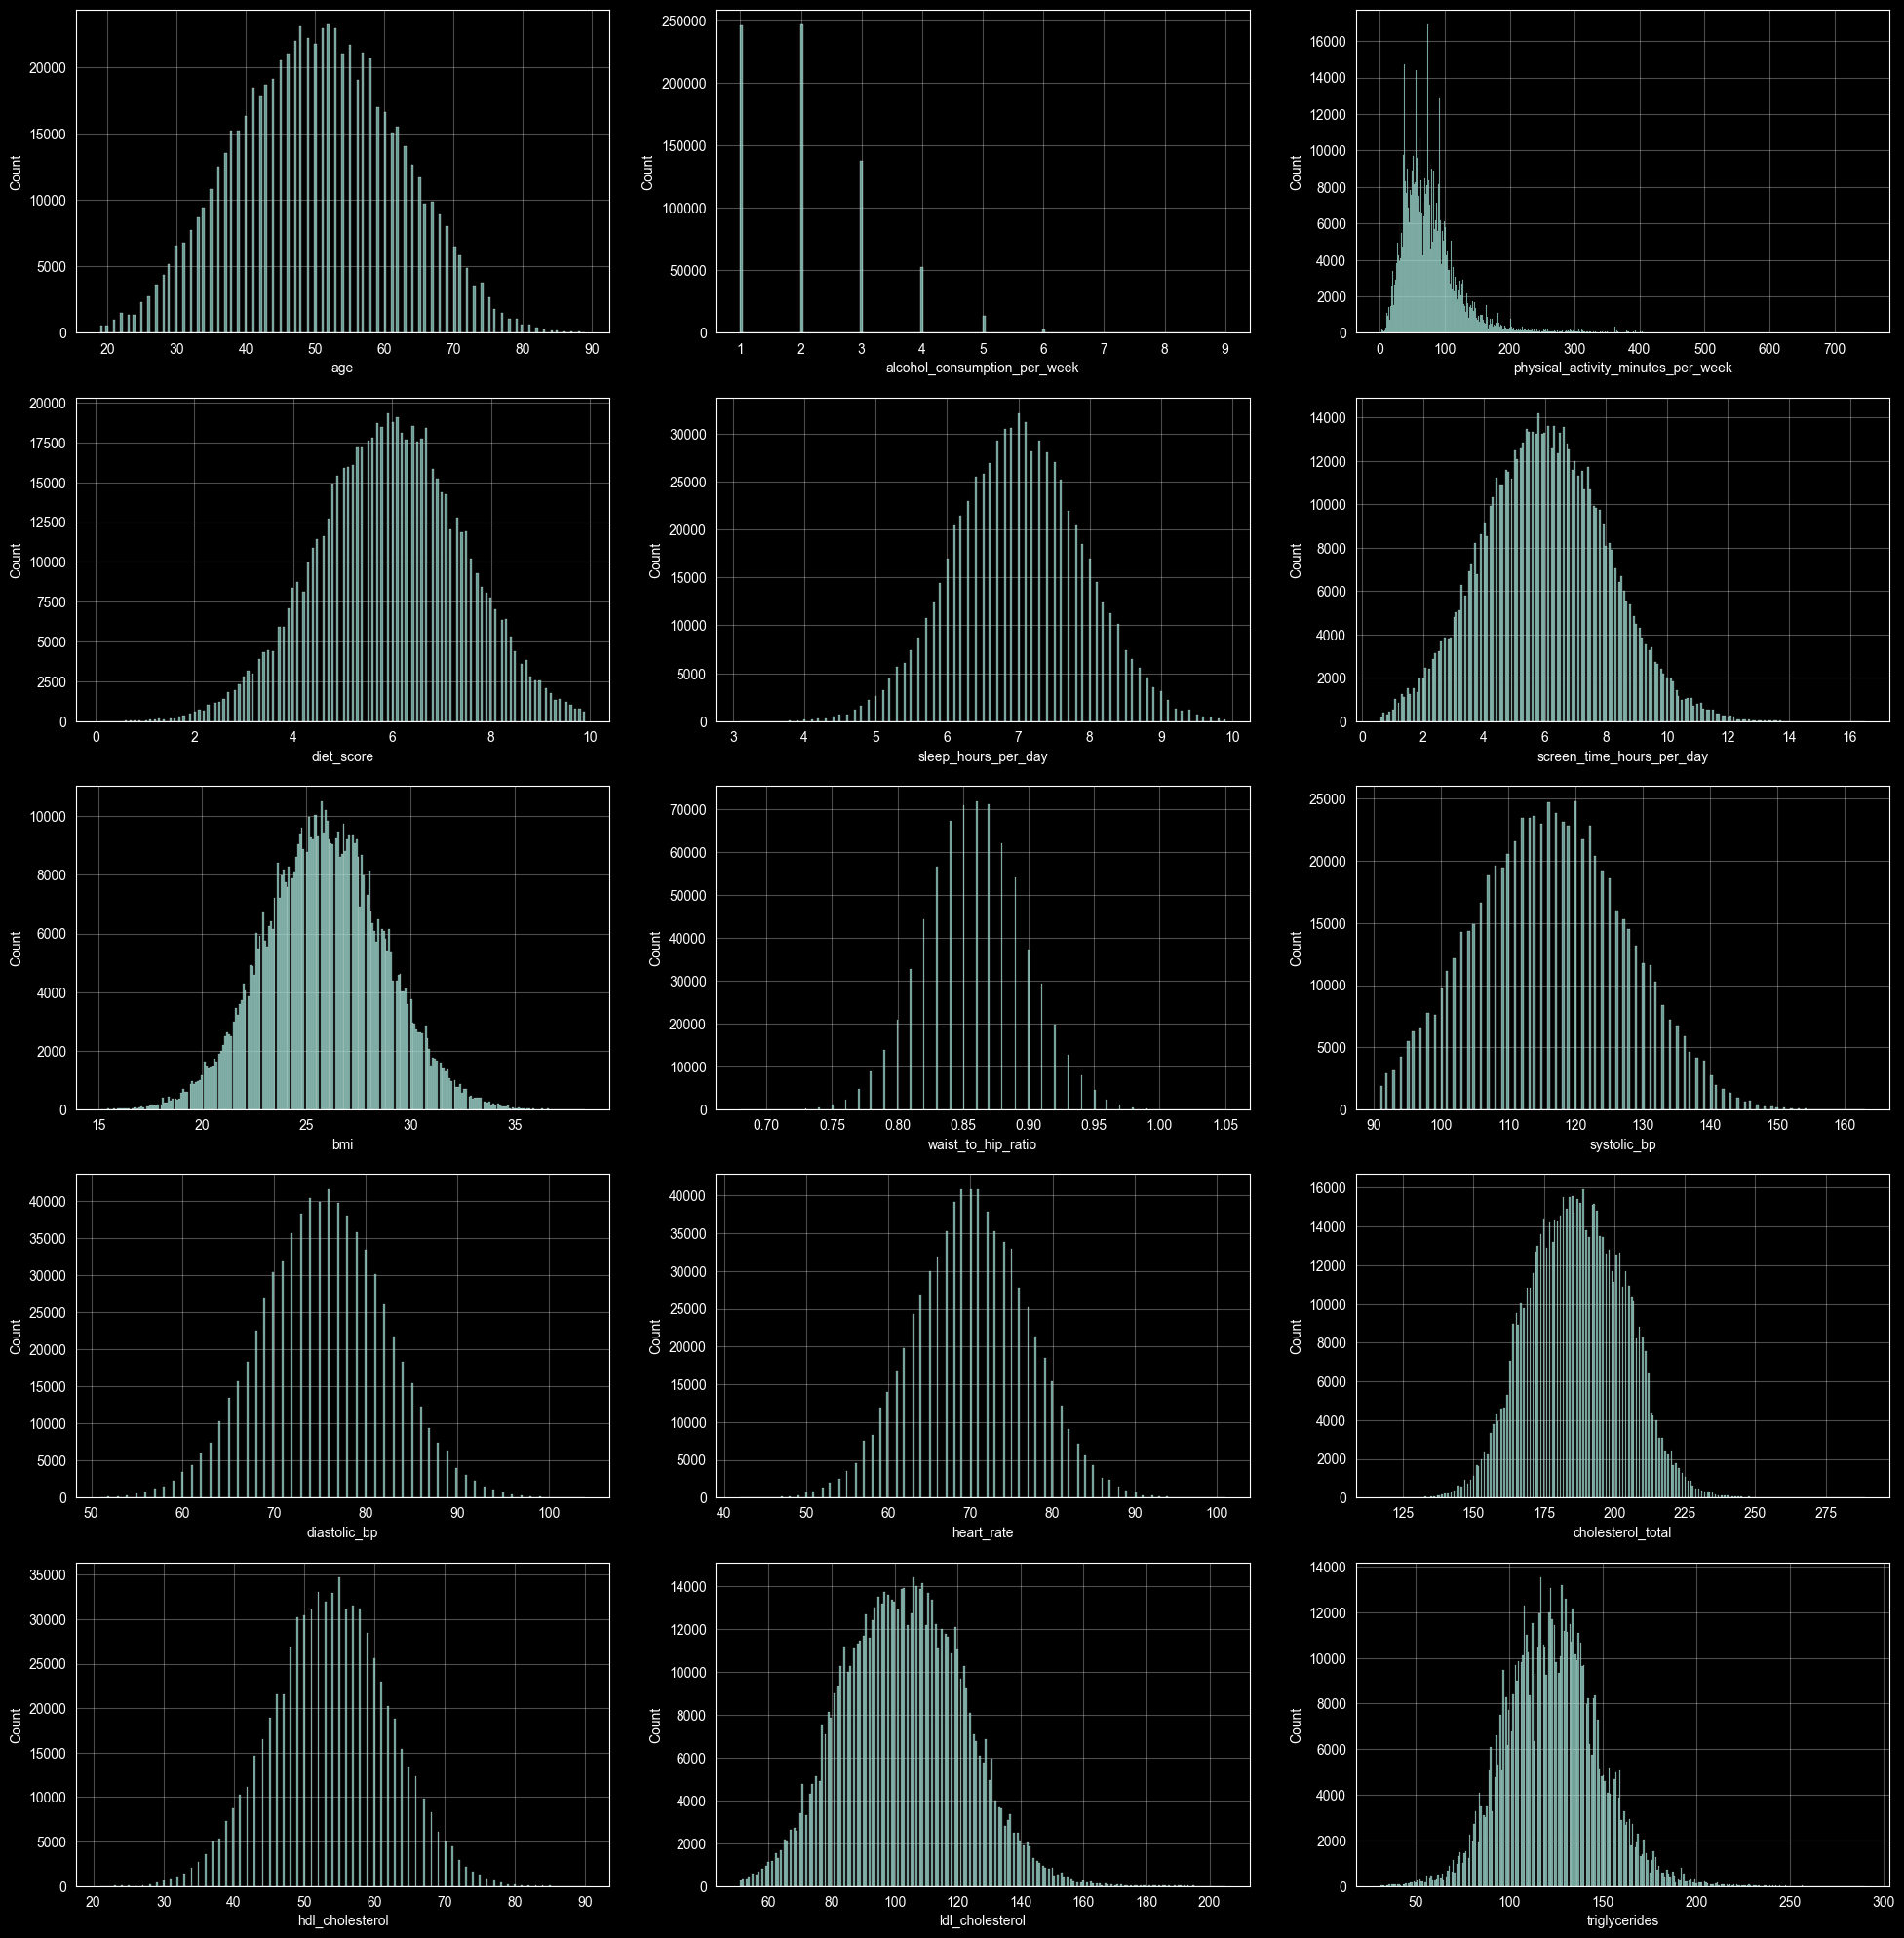

In [9]:
numerical = train.iloc[:, 1:16].select_dtypes(include = "number").columns.tolist()
n_cols = 3
n_rows = (len(numerical) + n_cols - 1) // n_cols
plt.figure(figsize = (8*n_cols, 5*n_rows))
for i, col in enumerate(numerical):
    ax = plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(data = train, x = col, ax = ax)
    ax.grid(True, alpha = 0.3)


### Numerical EDA
We see a lot of bell shaped graphs here which is nice, the only ones not perfectly normal shaped would be alcohol consumption and physical activity. These are ones I am not suprised to see a bit more variability in.

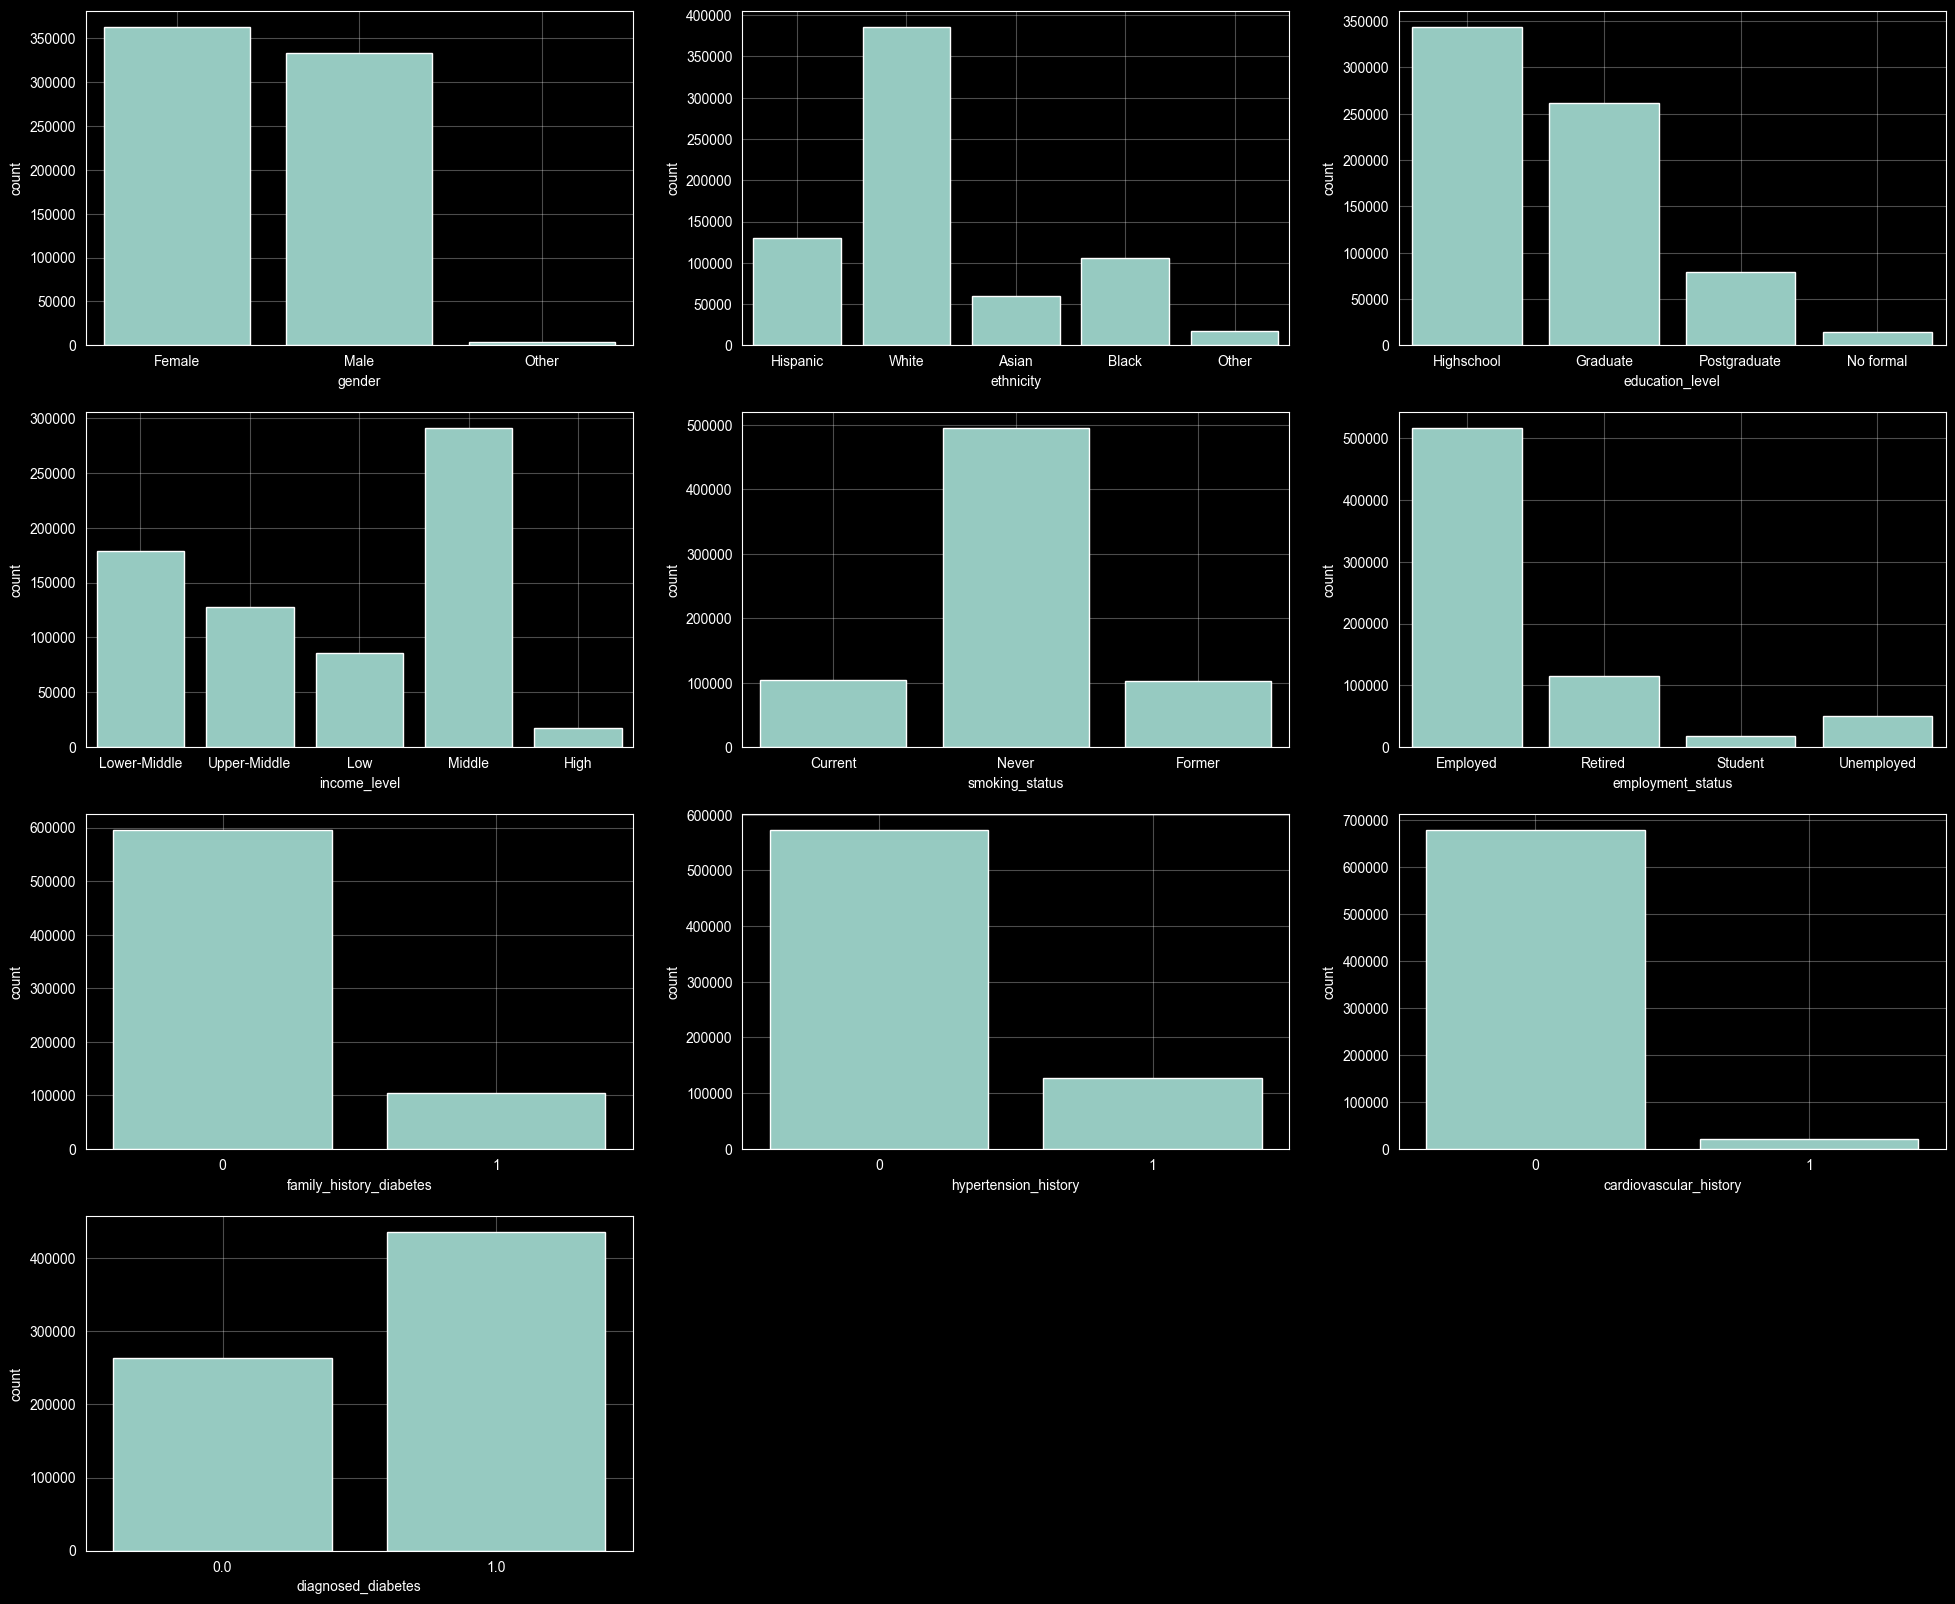

In [10]:
categorical_cols = train.iloc[:, -10:].columns.tolist()

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
plt.figure(figsize = (8*n_cols, 5*n_rows))
for i, col in enumerate(categorical_cols):
    ax = plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data = train, x = col, ax = ax)
    ax.grid(True, alpha = 0.3)

### Categorical EDA
We can see that there are good spreads within each column, some of the categories have a very small amount like "other" categories, but that should be ok.

## Multivarate EDA

Text(0.5, 1.0, 'Correlation Matrix')

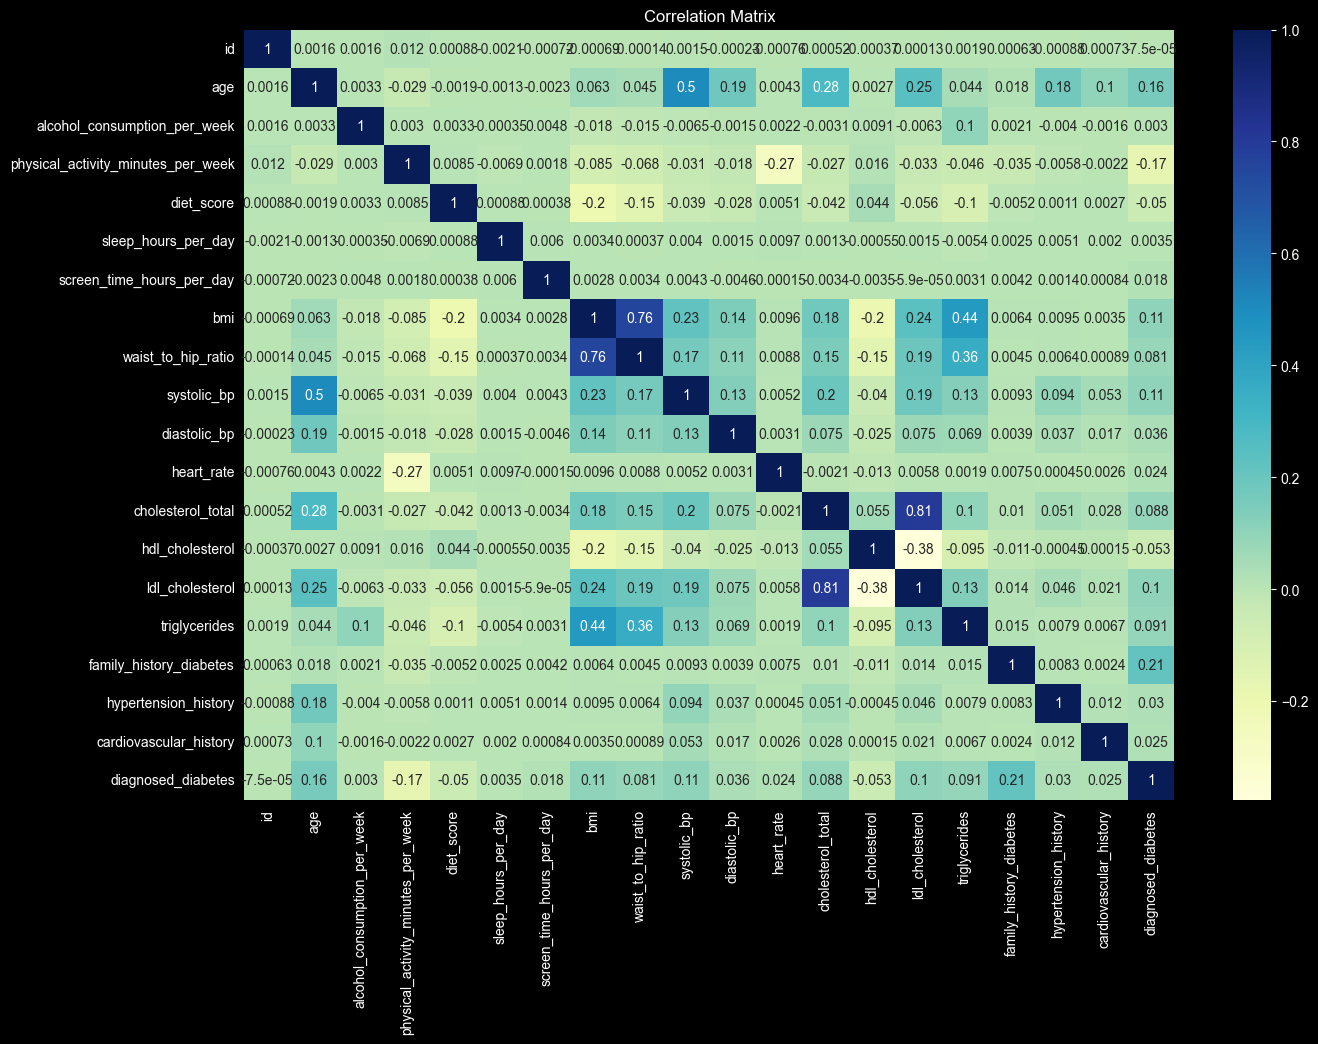

In [11]:
corr = train.corr(numeric_only=True)
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot = True, cmap = "YlGnBu")
plt.title("Correlation Matrix")

Text(0.5, 1.0, 'Absolute Value Correlation to diagnosed_diabetes')

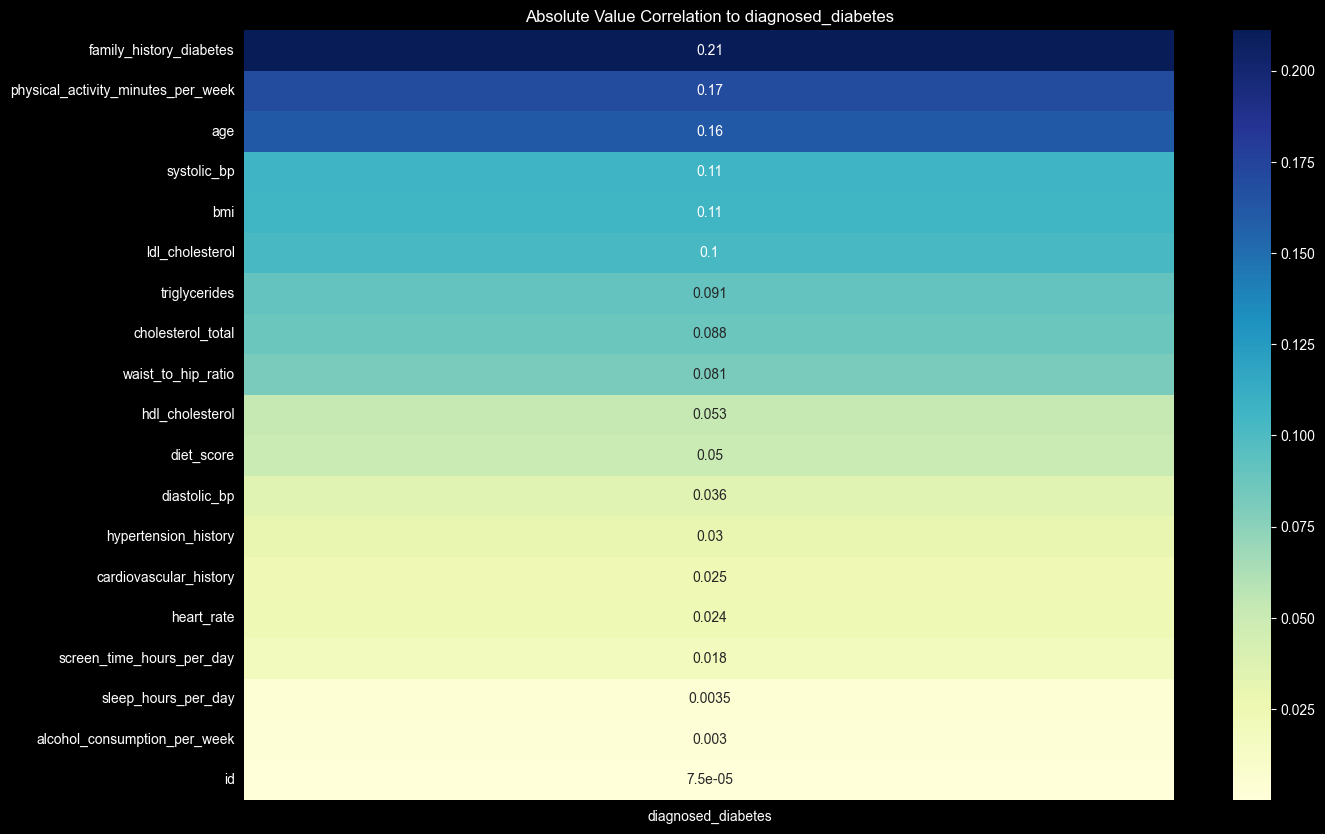

In [12]:
corr_target = (train.corr(numeric_only=True)["diagnosed_diabetes"].drop("diagnosed_diabetes").abs().sort_values(ascending = False))
plt.figure(figsize=(15,10))
sns.heatmap(corr_target.to_frame(), annot = True, cmap = "YlGnBu")
plt.title("Absolute Value Correlation to diagnosed_diabetes")

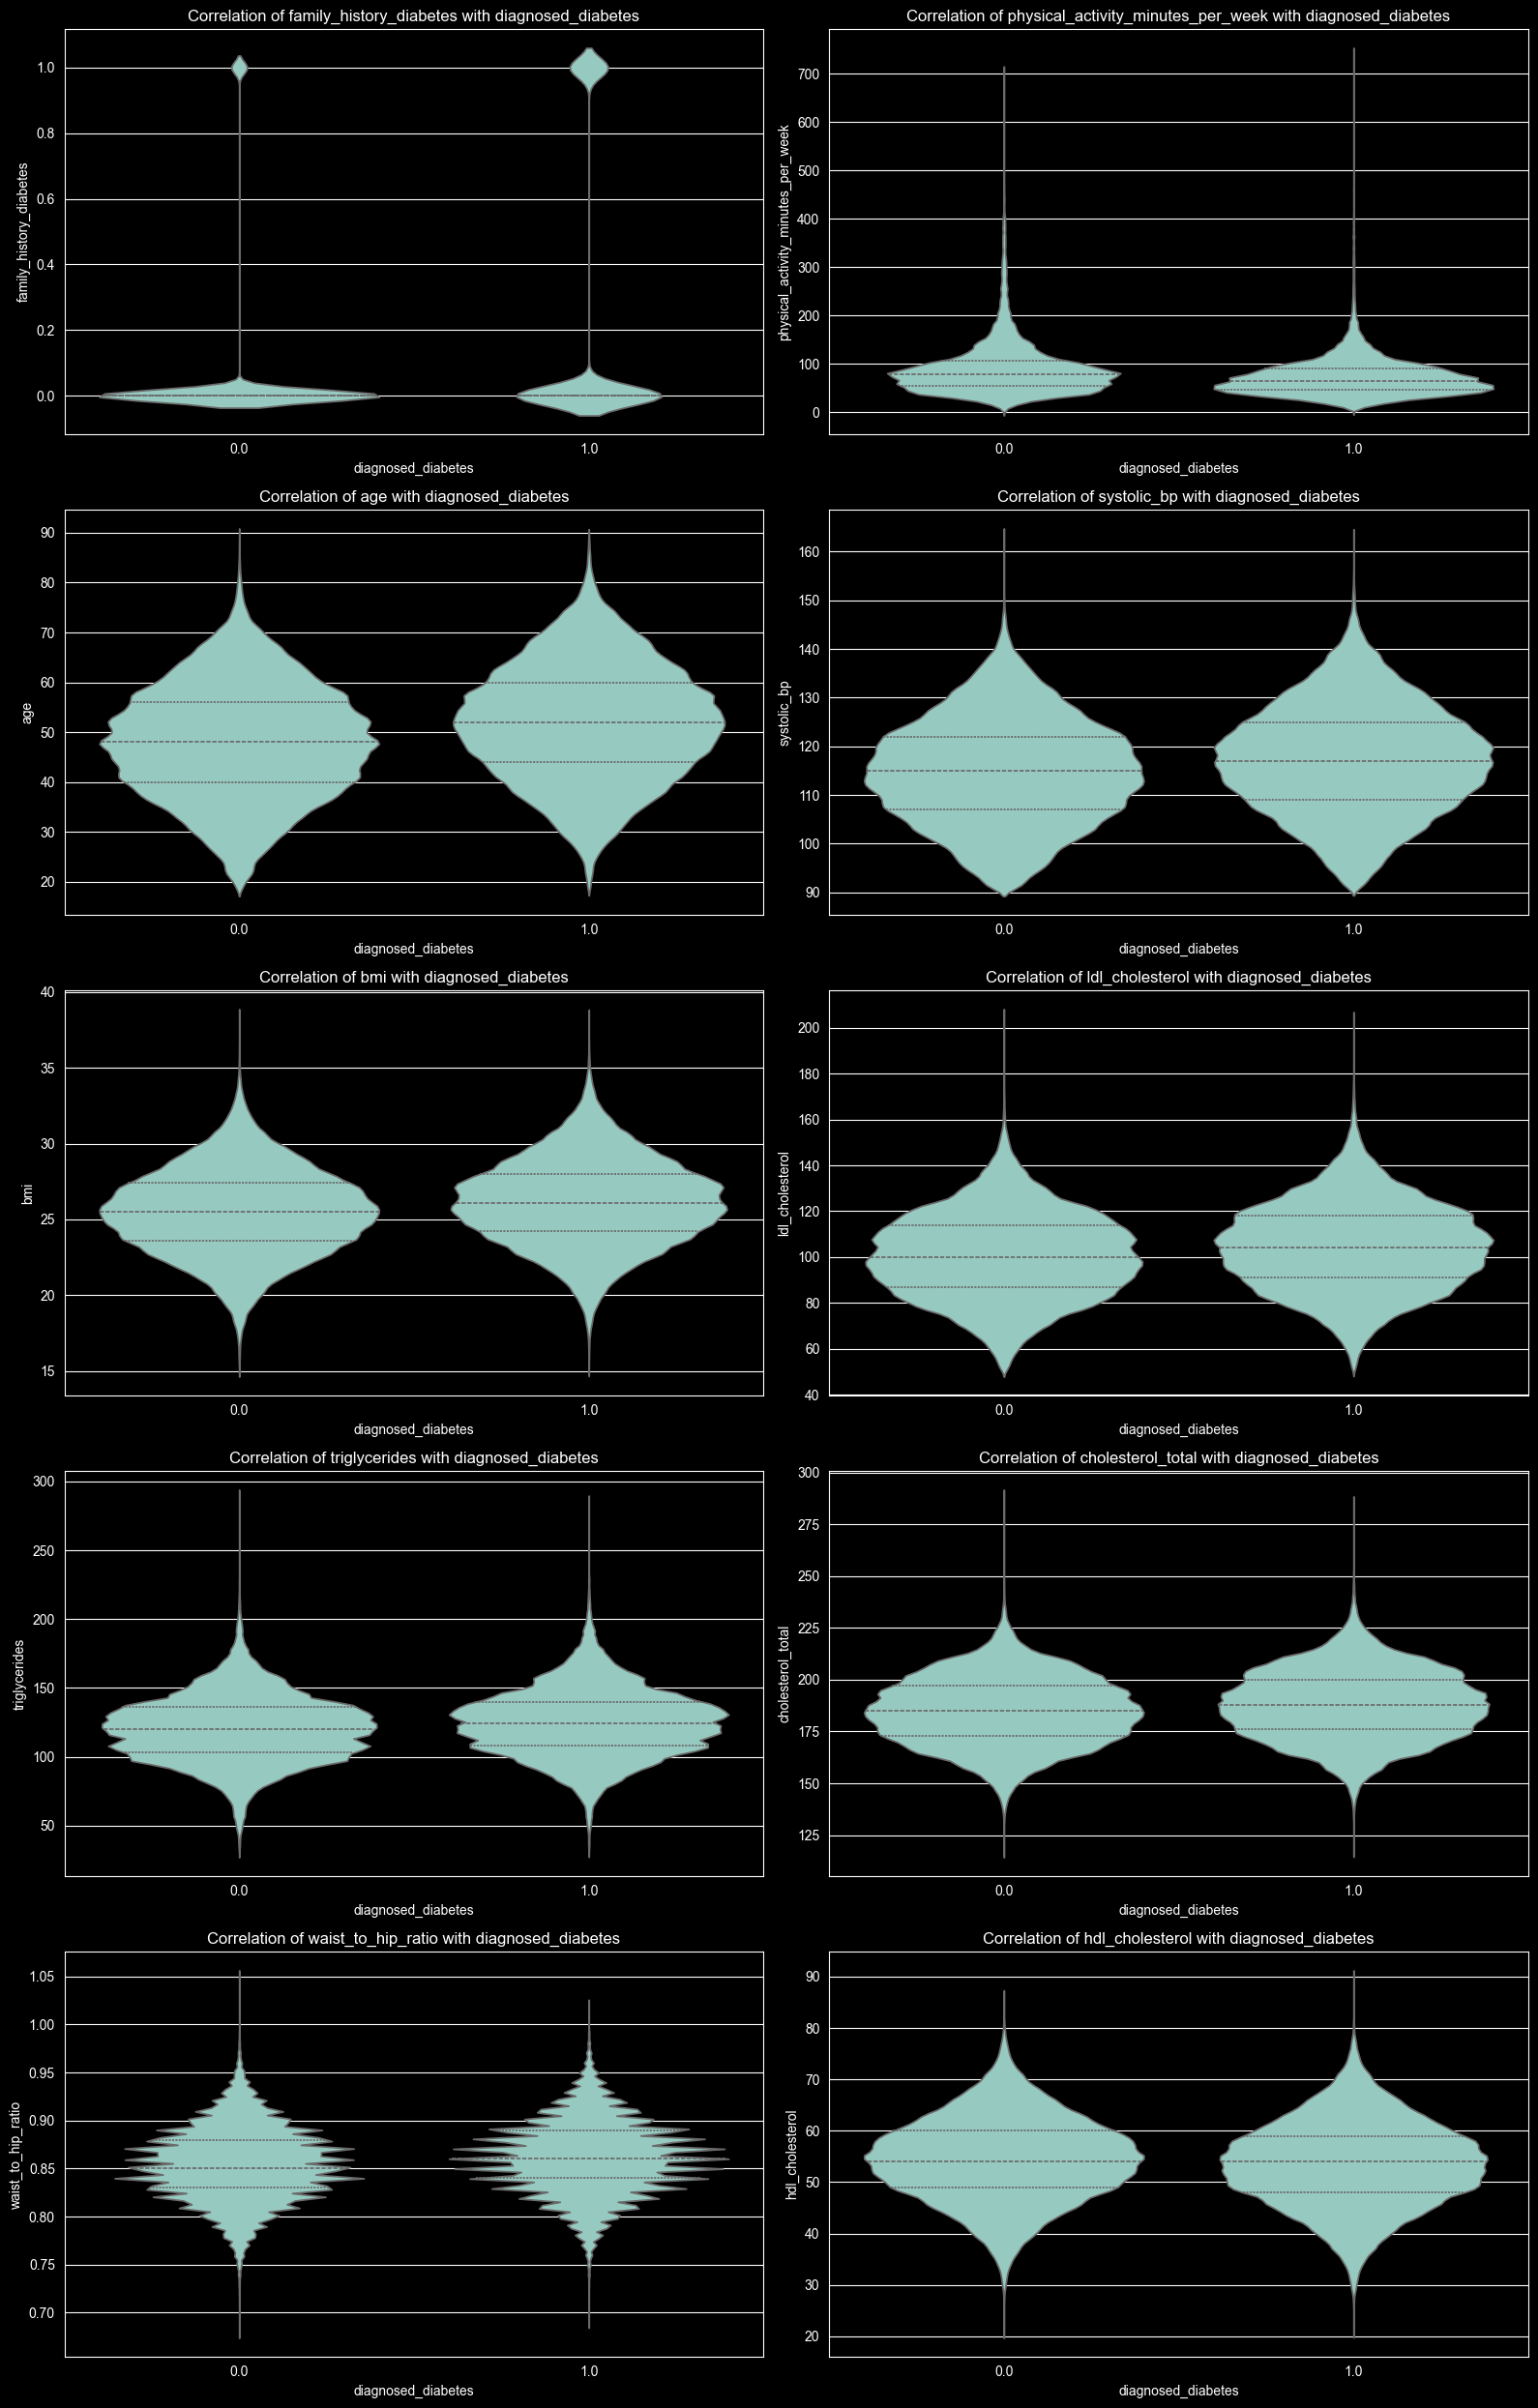

In [13]:
top10_features = corr_target.head(10).index.tolist()
n_cols = 2
n_rows = (len(top10_features) + n_cols - 1) // n_cols

plt.figure(figsize = (8*n_cols, 5*n_rows))

for i, col in enumerate(top10_features):
    ax = plt.subplot(n_rows, n_cols, i+1)
    sns.violinplot(data = train, y = col, x = "diagnosed_diabetes", ax = ax, inner="quartile")
    ax.set_title(f"Correlation of {col} with diagnosed_diabetes")
plt.tight_layout()
plt.show()


In [14]:
train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


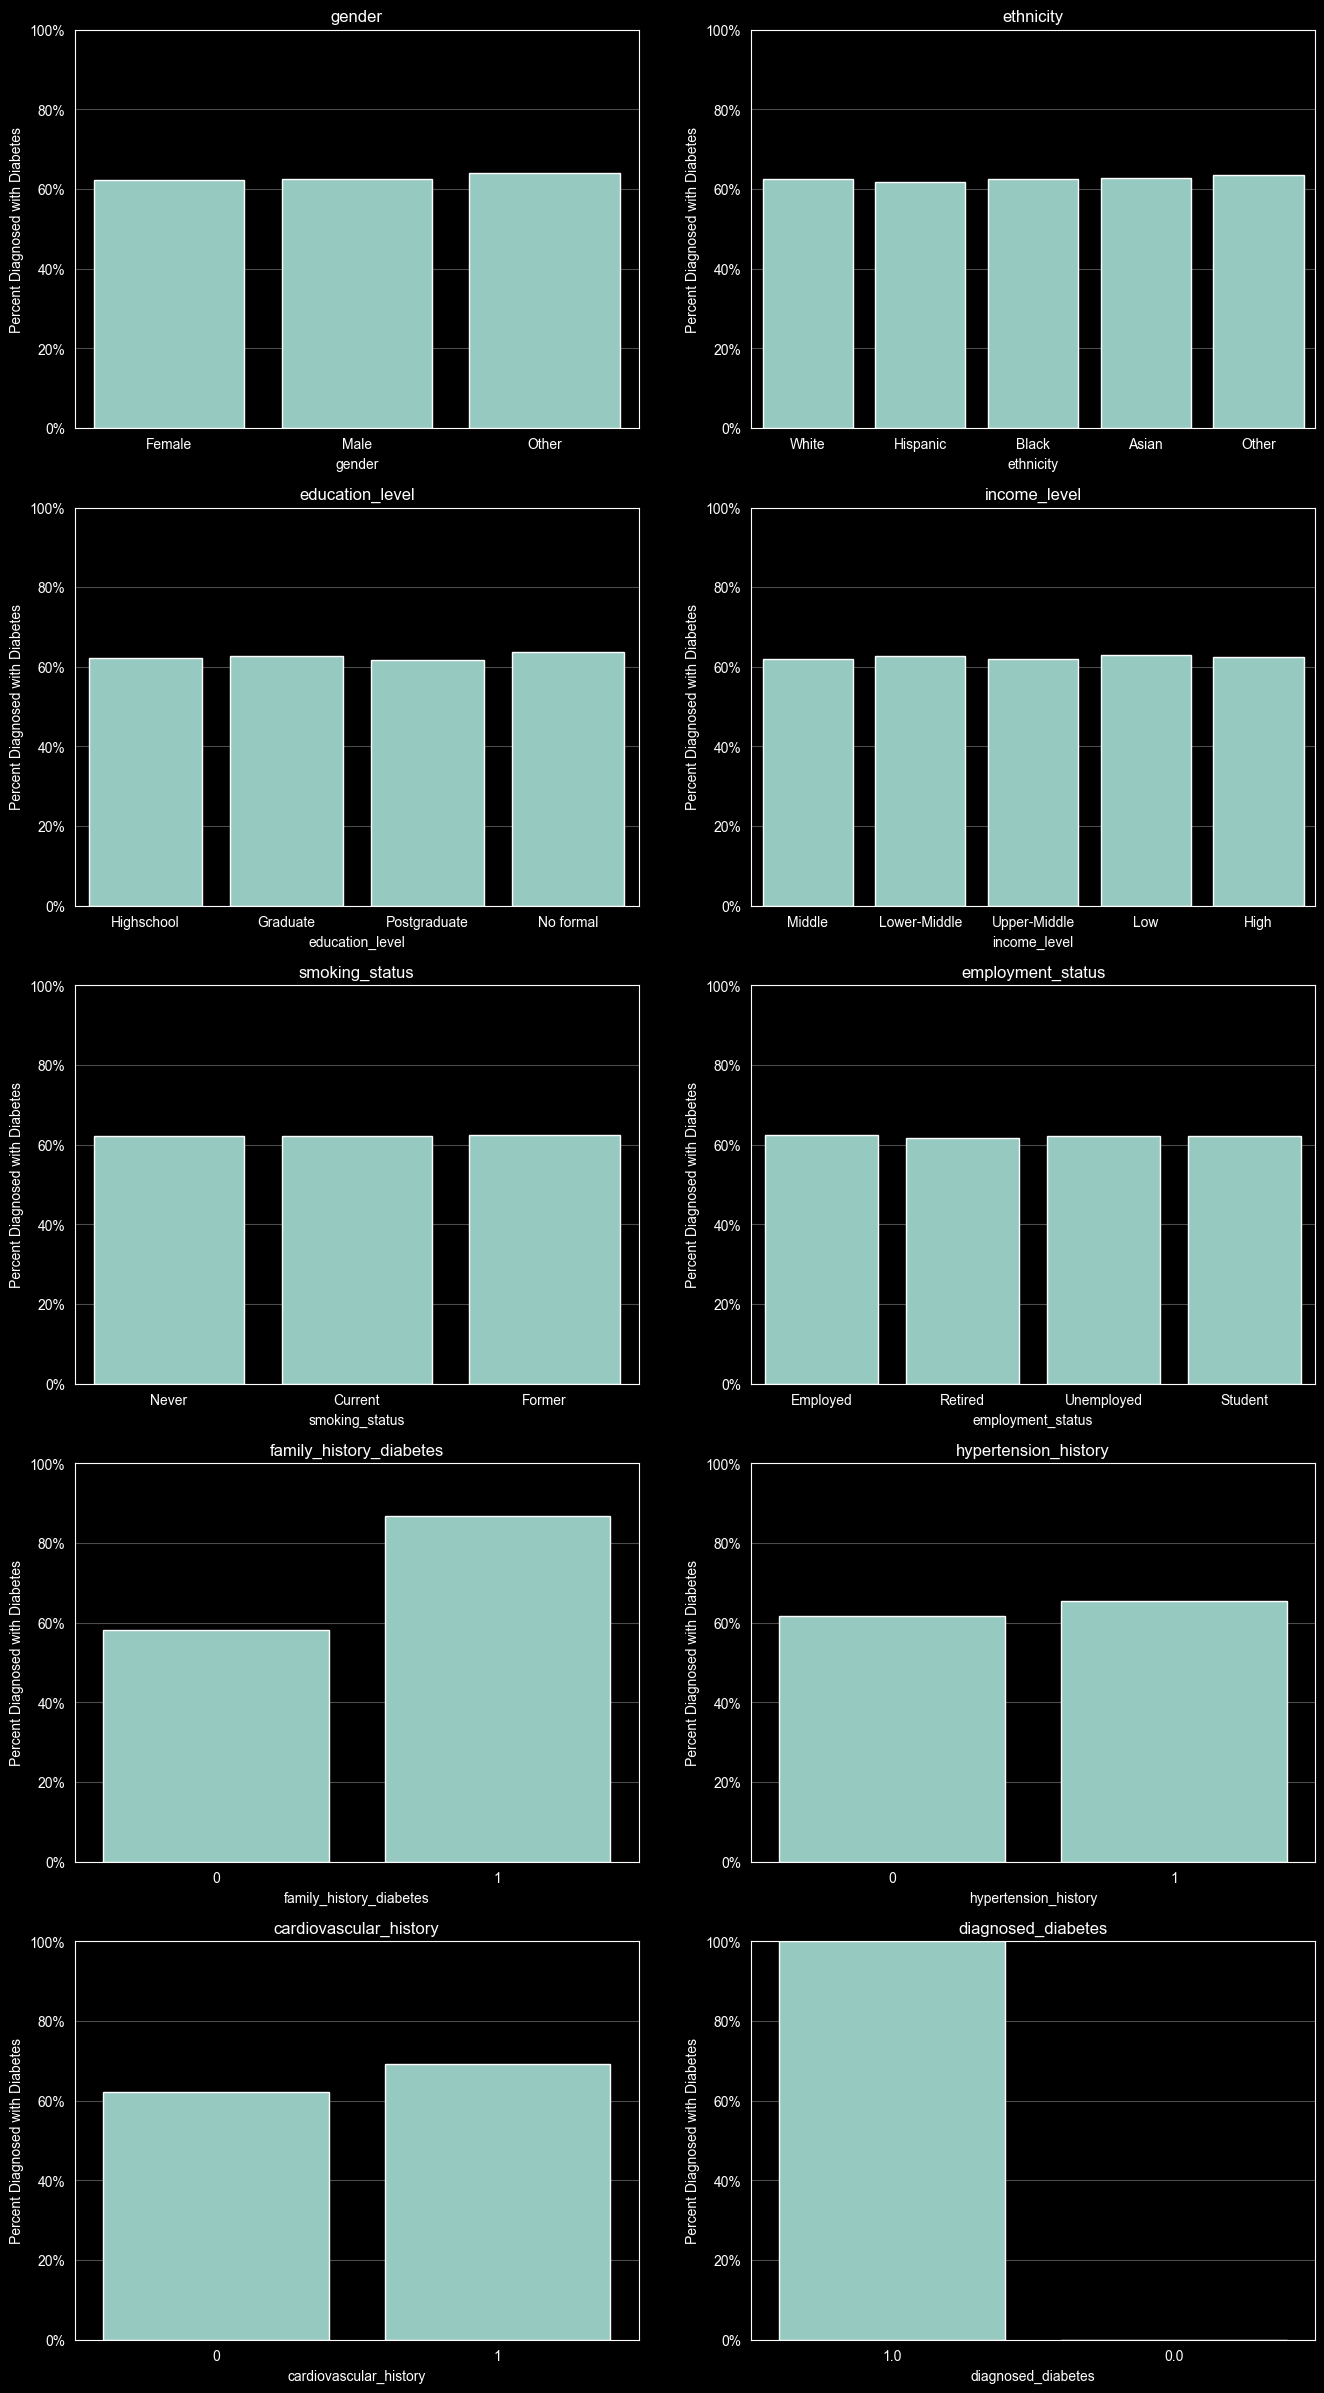

In [15]:
fig, axes = plt.subplots(5,2 , figsize = (8*n_cols, 6*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = train[col].value_counts().index
    sns.barplot(data = train, x = col, y="diagnosed_diabetes", ax = axes[i], order = order, estimator="mean", errorbar=None)

    axes[i].set_title(col)
    axes[i].set_ylabel("Percent Diagnosed with Diabetes")
    axes[i].set_ylim(0, 1)
    axes[i].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    axes[i].grid(True, axis="y", alpha=0.3)

It looks like the biggest difference in having diabetes between these categorical columns is with family_history_diabetes, hypertension_history, and cardiovascular_history.

# Model Training

In [16]:
train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

train.drop("id", axis=1)

numeric_features = ["age", "alcohol_consumption_per_week", "physical_activity_minutes_per_week", "diet_score", "sleep_hours_per_day", "screen_time_hours_per_day", "bmi", "waist_to_hip_ratio", "systolic_bp", "diastolic_bp", "heart_rate", "cholesterol_total", "hdl_cholesterol", "ldl_cholesterol", "triglycerides"]
binary_numeric = ["family_history_diabetes", "hypertension_history", "cardiovascular_history"]

ordinal_categorical = ["education_level", "income_level"]
ed_order = ["No formal", "Highschool", "Graduate", "Postgraduate"]
income_order = ["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"]


categorical_features = ["gender", "ethnicity", "smoking_status", "employment_status"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough", binary_numeric),
    ("ordinal", OrdinalEncoder(categories=[ed_order, income_order], handle_unknown="use_encoded_value", unknown_value=-1), ordinal_categorical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])



In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.model_selection import cross_val_score

X = train.drop("diagnosed_diabetes", axis = 1)
y = train["diagnosed_diabetes"]



In [30]:
logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter = 1000))
])

cross_val = cross_val_score(logreg, X, y, cv = 5, scoring = "roc_auc", n_jobs = -1).mean()
print("Logistic Regression AUC ROC:", cross_val)


Logistic Regression AUC ROC: 0.6943327940725988


In [31]:
from xgboost import XGBClassifier
xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier())
])

cross_val = cross_val_score(xgb, X, y, cv = 5, scoring = "roc_auc", n_jobs = -1).mean()
print("XGBoost AUC ROC:", cross_val)

XGBoost AUC ROC: 0.7222497976082505


In [32]:
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=50_000, random_state = 42, stratify=y)

import optuna
def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": 1,


        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.15, log=True),

        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),

        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(**params))
    ])

    score = cross_val_score(model, X_sub, y_sub, cv = 5, scoring = "roc_auc", n_jobs = -1).mean()

    return score

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 50)

print("Best ROC AUC:", study.best_value)
print("Best Hyperparameters:", study.best_params)

[I 2026-01-09 17:10:28,320] A new study created in memory with name: no-name-a8db2501-491f-486c-81c9-79f91ea61c21
[I 2026-01-09 17:10:31,585] Trial 0 finished with value: 0.7119302362793137 and parameters: {'n_estimators': 496, 'learning_rate': 0.07726598534398703, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.895329084379938, 'colsample_bytree': 0.8514780177887002, 'gamma': 0.8618203397548589, 'reg_lambda': 4.320747560683454}. Best is trial 0 with value: 0.7119302362793137.
[I 2026-01-09 17:10:36,237] Trial 1 finished with value: 0.705914344516421 and parameters: {'n_estimators': 800, 'learning_rate': 0.08032950286397789, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.7120584805254594, 'colsample_bytree': 0.8161865001217978, 'gamma': 0.5942141148078388, 'reg_lambda': 1.098372464218667}. Best is trial 0 with value: 0.7119302362793137.
[I 2026-01-09 17:10:39,149] Trial 2 finished with value: 0.6951075249605927 and parameters: {'n_estimators': 426, 'learning_rate': 0.11649

Best ROC AUC: 0.712108990608956
Best Hyperparameters: {'n_estimators': 546, 'learning_rate': 0.09461111765913752, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.854990989679192, 'colsample_bytree': 0.9956313743402825, 'gamma': 1.7926662985997233, 'reg_lambda': 0.7462829470369989}


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state = 42, stratify = y)

xgb.fit(X_train, y_train)

final_preds_xgb = xgb.predict_proba(X_test)[:, 1]

best_params = study.best_params
optuna_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(**best_params,
                            objective="binary:logistic",
                            eval_metric="auc",
                            tree_method="hist",
                            random_state=42,
                            n_jobs=-1
                            ))
])

optuna_xgb.fit(X_train, y_train)
final_preds_optuna = optuna_xgb.predict_proba(X_test)[:, 1]

print("Base XGB Test ROC AUC:", roc_auc_score(y_test, final_preds_xgb))
print("Optuna XGB Test ROC AUC:", roc_auc_score(y_test, final_preds_optuna))

Base XGB Test ROC AUC: 0.7226342535097873
Optuna XGB Test ROC AUC: 0.7228623809100945


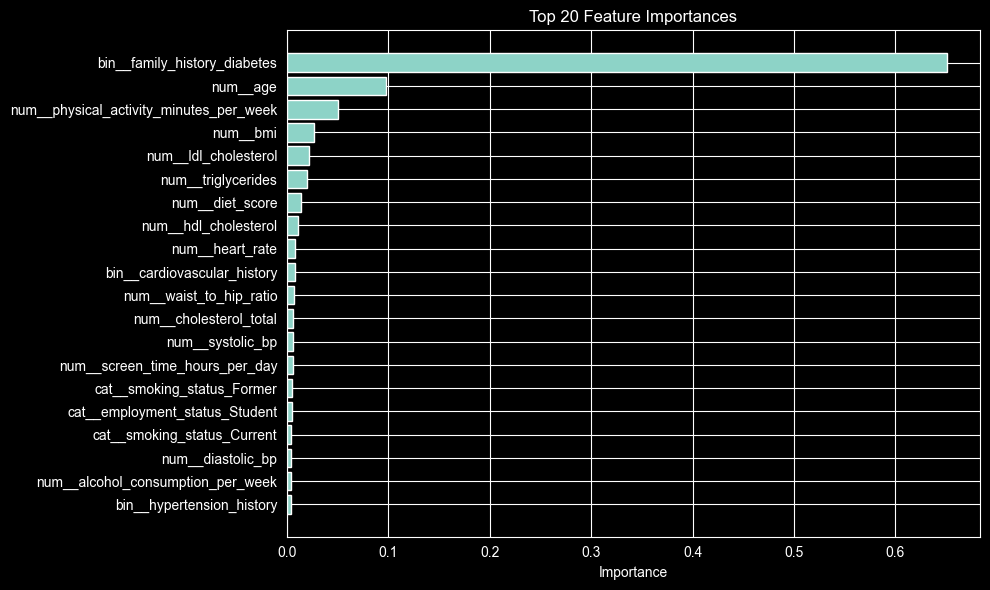

In [48]:
from xgboost import plot_importance
from xgboost import plot_importance
model = optuna_xgb.named_steps["model"]
feature_names = optuna_xgb.named_steps["preprocessor"].get_feature_names_out()

imp_df = (pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})
.sort_values("importance", ascending=False)
.head(20))

plt.figure(figsize=(10, 6))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [49]:
X_test = test.drop("id", axis = 1)
test_probs = optuna_xgb.predict_proba(X_test)[:, 1]
test_probs

array([0.51259345, 0.6769391 , 0.76072466, ..., 0.56548905, 0.6238195 ,
       0.59508634], shape=(300000,), dtype=float32)

In [51]:
submission = pd.DataFrame({
    "id": test["id"],
    "diagnosed_diabetes": test_probs
})
submission.head()

,id,diagnosed_diabetes
0,700000,0.512593
1,700001,0.676939
2,700002,0.760725
3,700003,0.413541
4,700004,0.919960


In [53]:
submission.to_csv("submission.csv", index = False)

In [54]:
submission.head()

,id,diagnosed_diabetes
0,700000,0.512593
1,700001,0.676939
2,700002,0.760725
3,700003,0.413541
4,700004,0.919960
